In [4]:
import pandas as pd
import numpy as np

print("Ingesting MoMA datasets via GitHub LFS media endpoint...")


artworks_url = "https://media.githubusercontent.com/media/MuseumofModernArt/collection/main/Artworks.csv"
artists_url = "https://media.githubusercontent.com/media/MuseumofModernArt/collection/main/Artists.csv"


df_artworks = pd.read_csv(artworks_url, low_memory=False)
df_artists = pd.read_csv(artists_url, low_memory=False)

print(f"Successfully loaded Artworks shape: {df_artworks.shape}")
print(f"Successfully loaded Artists shape: {df_artists.shape}")

# --- Data Cleaning & Feature Engineering ---

df_artworks['DateAcquired'] = pd.to_datetime(df_artworks['DateAcquired'], errors='coerce')
df_artworks['AcquisitionYear'] = df_artworks['DateAcquired'].dt.year


df_artworks['CleanYear'] = pd.to_numeric(
    df_artworks['Date'].astype(str).str.extract(r'(\d{4})')[0],
    errors='coerce'
)

# 3. Clean categorical strings for analysis
df_artworks['Department'] = df_artworks['Department'].str.strip()
df_artworks['Classification'] = df_artworks['Classification'].str.strip()


print("\nTop Curatorial Departments in Collection:")
print(df_artworks['Department'].value_counts().head(5))

print("\nPipeline ready. Data structures validated.")

Ingesting MoMA datasets via GitHub LFS media endpoint...
Successfully loaded Artworks shape: (160598, 30)
Successfully loaded Artists shape: (15933, 9)

Top Curatorial Departments in Collection:
Department
Drawings & Prints        82113
Architecture & Design    34539
Photography              33825
Painting & Sculpture      4093
Media and Performance     3295
Name: count, dtype: int64

Pipeline ready. Data structures validated.


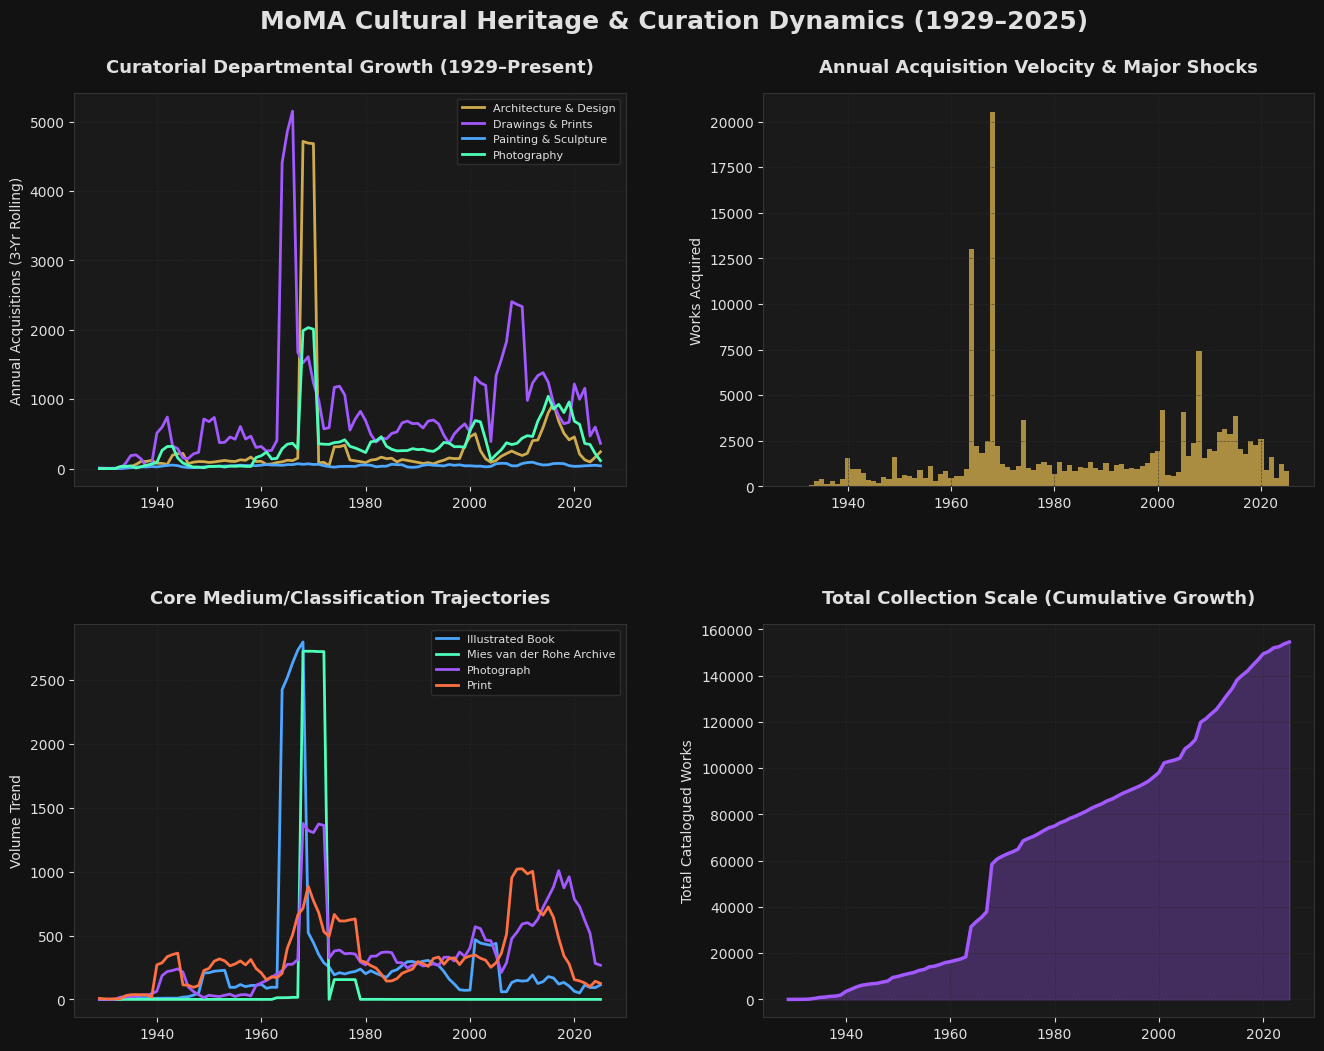

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Aggregation for the 4 Panels ---


df_valid = df_artworks[(df_artworks['AcquisitionYear'] >= 1929) & (df_artworks['AcquisitionYear'] <= 2025)].copy()

# Panel 1: Medium / Department Evolution over Decades (Top 4 departments)
top_depts = df_valid['Department'].value_counts().head(4).index.tolist()
df_dept_time = df_valid[df_valid['Department'].isin(top_depts)]
dept_pivot = pd.pivot_table(
    df_dept_time,
    index='AcquisitionYear',
    columns='Department',
    values='ObjectID',
    aggfunc='count',
    fill_value=0
).rolling(window=3, min_periods=1).mean() # Smoothed trend

# Panel 2: Annual Acquisition Velocity
annual_acquisitions = df_valid.groupby('AcquisitionYear')['ObjectID'].count()

# Panel 3: Top Artist Nationalities (from Artists dataset if available, or Classification breakdown)
top_classifications = df_valid['Classification'].value_counts().head(4).index.tolist()
df_class_time = df_valid[df_valid['Classification'].isin(top_classifications)]
class_pivot = pd.pivot_table(
    df_class_time,
    index='AcquisitionYear',
    columns='Classification',
    values='ObjectID',
    aggfunc='count',
    fill_value=0
).rolling(window=5, min_periods=1).mean()

# Panel 4: Cumulative Curation Scale
cumulative_acquisitions = annual_acquisitions.cumsum()


# --- 2. Design System & 4-Panel Plotting ---


BG_COLOR = "#121212"
PANEL_BG = "#1a1a1a"
TEXT_COLOR = "#e0e0e0"
ACCENT_GOLD = "#d0ab4d"
ACCENT_PURPLE = "#a259ff"
ACCENT_BLUE = "#4da6ff"
ACCENT_GREEN = "#4dffb8"

fig = plt.figure(figsize=(16, 12), facecolor=BG_COLOR)
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = TEXT_COLOR
plt.rcParams['axes.labelcolor'] = TEXT_COLOR
plt.rcParams['xtick.color'] = TEXT_COLOR
plt.rcParams['ytick.color'] = TEXT_COLOR

def style_axis(ax, title):
    ax.set_facecolor(PANEL_BG)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15, color=TEXT_COLOR)
    ax.grid(True, color='#2a2a2a', linestyle='--', linewidth=0.5, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# --- Panel 1: Departmental Acquisition Trends ---
ax1 = fig.add_subplot(gs[0, 0])
style_axis(ax1, "Curatorial Departmental Growth (1929–Present)")
colors = [ACCENT_GOLD, ACCENT_PURPLE, ACCENT_BLUE, ACCENT_GREEN]
for i, col in enumerate(dept_pivot.columns):
    ax1.plot(dept_pivot.index, dept_pivot[col], label=col, color=colors[i], linewidth=2)
ax1.set_ylabel("Annual Acquisitions (3-Yr Rolling)", fontsize=10)
ax1.legend(facecolor=BG_COLOR, edgecolor='#333333', fontsize=8, labelcolor=TEXT_COLOR)

# --- Panel 2: Acquisition Velocity & Institutional Spikes ---
ax2 = fig.add_subplot(gs[0, 1])
style_axis(ax2, "Annual Acquisition Velocity & Major Shocks")
ax2.bar(annual_acquisitions.index, annual_acquisitions.values, color=ACCENT_GOLD, alpha=0.8, width=1.0)
ax2.set_ylabel("Works Acquired", fontsize=10)

# --- Panel 3: Classification Evolution ---
ax3 = fig.add_subplot(gs[1, 0])
style_axis(ax3, "Core Medium/Classification Trajectories")
class_colors = [ACCENT_BLUE, ACCENT_GREEN, ACCENT_PURPLE, '#ff7043']
for i, col in enumerate(class_pivot.columns):
    ax3.plot(class_pivot.index, class_pivot[col], label=col, color=class_colors[i], linewidth=2)
ax3.set_ylabel("Volume Trend", fontsize=10)
ax3.legend(facecolor=BG_COLOR, edgecolor='#333333', fontsize=8, labelcolor=TEXT_COLOR)

# --- Panel 4: Cumulative Collection Scale ---
ax4 = fig.add_subplot(gs[1, 1])
style_axis(ax4, "Total Collection Scale (Cumulative Growth)")
ax4.fill_between(cumulative_acquisitions.index, cumulative_acquisitions.values, color=ACCENT_PURPLE, alpha=0.3)
ax4.plot(cumulative_acquisitions.index, cumulative_acquisitions.values, color=ACCENT_PURPLE, linewidth=2.5)
ax4.set_ylabel("Total Catalogued Works", fontsize=10)

# Main Title Header
fig.suptitle("MoMA Cultural Heritage & Curation Dynamics (1929–2025)",
             fontsize=18, fontweight='bold', color=TEXT_COLOR, y=0.95)

plt.show()